# **1. Perkenalan Dataset**


## Informasi Dataset

**Nama Dataset:** Bank Customer Churn Prediction  
**Sumber:** Dicoding — Latihan Studi Kasus: *Klasifikasi Pelanggan untuk Churn pada Perusahaan XYZ*  

### Deskripsi Dataset
Dataset ini berasal dari latihan studi kasus pada modul *Machine Learning Terapan* di Dicoding, yang membahas penerapan algoritma klasifikasi dalam konteks nyata. Latihan ini berfokus untuk membantu **Perusahaan XYZ** mengidentifikasi pelanggan yang berpotensi melakukan *churn* (berhenti menggunakan layanan bank). Dataset terdiri dari **10.000 baris** dan **14 kolom**, dengan kolom target `Exited` yang bernilai 1 (churn) atau 0 (tidak churn).

### Fitur-fitur dalam Dataset
| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| `RowNumber` | int | Nomor urut baris data |
| `CustomerId` | int | ID unik setiap nasabah |
| `Surname` | object | Nama belakang nasabah |
| `CreditScore` | int | Skor kredit nasabah (350–850) |
| `Geography` | object | Negara asal nasabah (France, Spain, Germany) |
| `Gender` | object | Jenis kelamin nasabah (Male / Female) |
| `Age` | int | Usia nasabah (18–92 tahun) |
| `Tenure` | int | Lama nasabah bergabung dengan bank (0–10 tahun) |
| `Balance` | float | Saldo rekening nasabah |
| `NumOfProducts` | int | Jumlah produk bank yang digunakan nasabah (1–4) |
| `HasCrCard` | int | Kepemilikan kartu kredit (0 = Tidak, 1 = Ya) |
| `IsActiveMember` | int | Status keaktifan nasabah (0 = Tidak Aktif, 1 = Aktif) |
| `EstimatedSalary` | float | Estimasi gaji tahunan nasabah |
| `Exited` | int | **Label Target**: nasabah churn (1) atau tidak churn (0) |

### Tujuan
Membangun dan membandingkan beberapa model klasifikasi untuk memprediksi kemungkinan *customer churn* berdasarkan fitur-fitur demografis dan perilaku finansial nasabah, sehingga Perusahaan XYZ dapat mengambil langkah preventif lebih awal.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [6]:
data = pd.read_csv('../churndataset_raw/churn_dataset_bmlp_3.csv')
#menampilkan dataset
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# Menampilkan informasi umum tentang dataset
print("\nInformasi dataset:")
data.info()


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [8]:
print("Missing values per fitur:")
print(data.isnull().sum())
print(f"\nTotal missing values: {data.isnull().sum().sum()}")


Missing values per fitur:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Total missing values: 0


In [9]:
print(f"Jumlah data sebelum hapus duplikat: {data.shape[0]}")
print(f"Jumlah baris duplikat: {data.duplicated().sum()}")

Jumlah data sebelum hapus duplikat: 10000
Jumlah baris duplikat: 0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

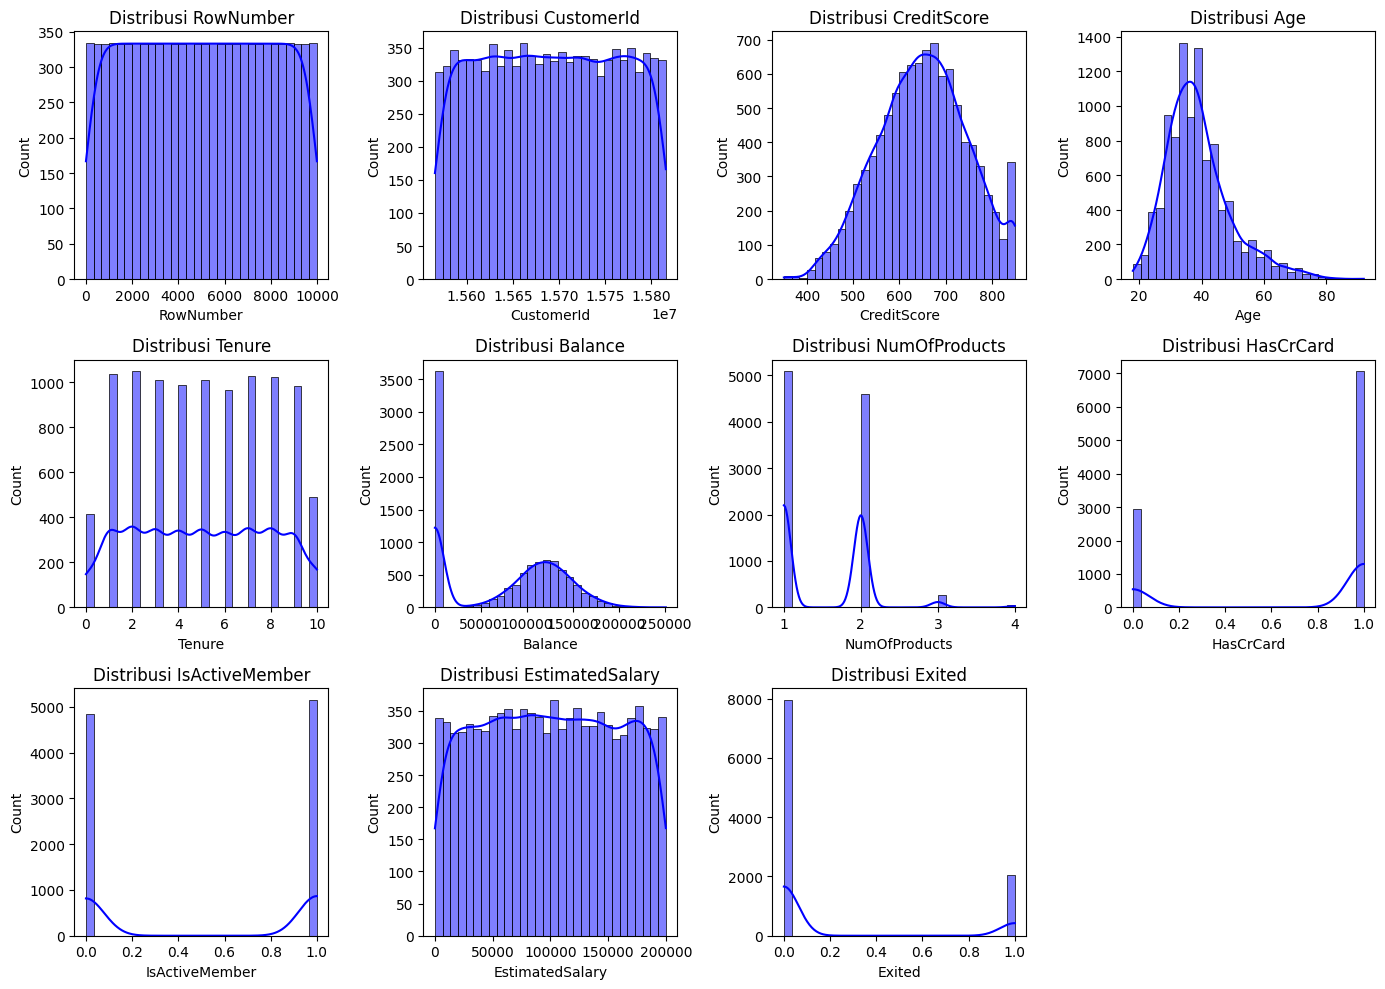

In [10]:
# Distribusi fitur numerik
num_features = data.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
for i, column in enumerate(num_features.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(data[column], bins=30, kde=True, color='blue')
    plt.title(f'Distribusi {column}')
plt.tight_layout()
plt.show()

/var/folders/x_/11jlv9j50d131r830tx300cw0000gn/T/ipykernel_4088/3769474563.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/x_/11jlv9j50d131r830tx300cw0000gn/T/ipykernel_4088/3769474563.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


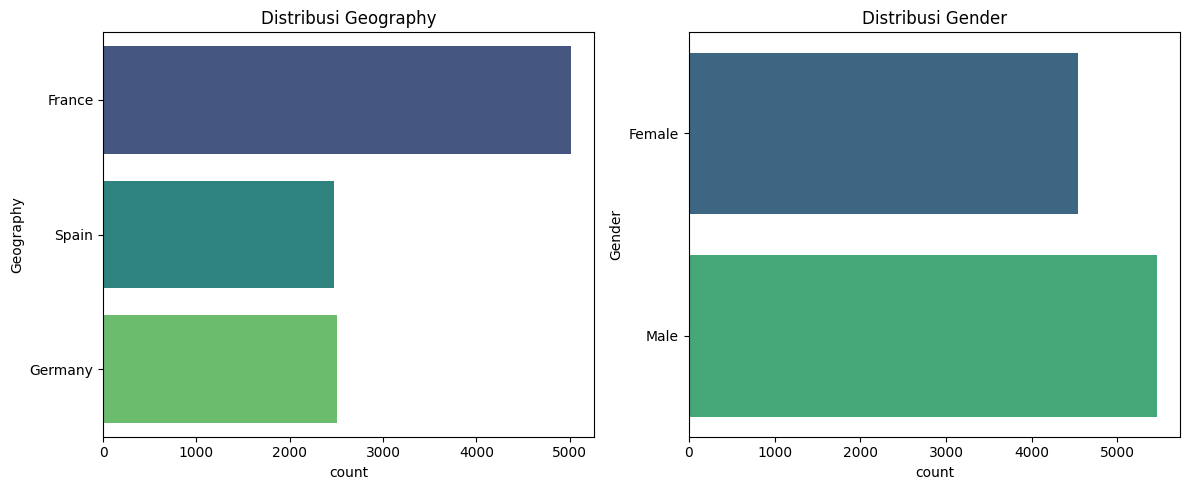

In [11]:
plt.figure(figsize=(12, 5))

# Geography
plt.subplot(1, 2, 1)
sns.countplot(
    y='Geography',
    data=data,
    palette='viridis'
)
plt.title('Distribusi Geography')

# Gender
plt.subplot(1, 2, 2)
sns.countplot(
    y='Gender',
    data=data,
    palette='viridis'
)
plt.title('Distribusi Gender')

plt.tight_layout()
plt.show()

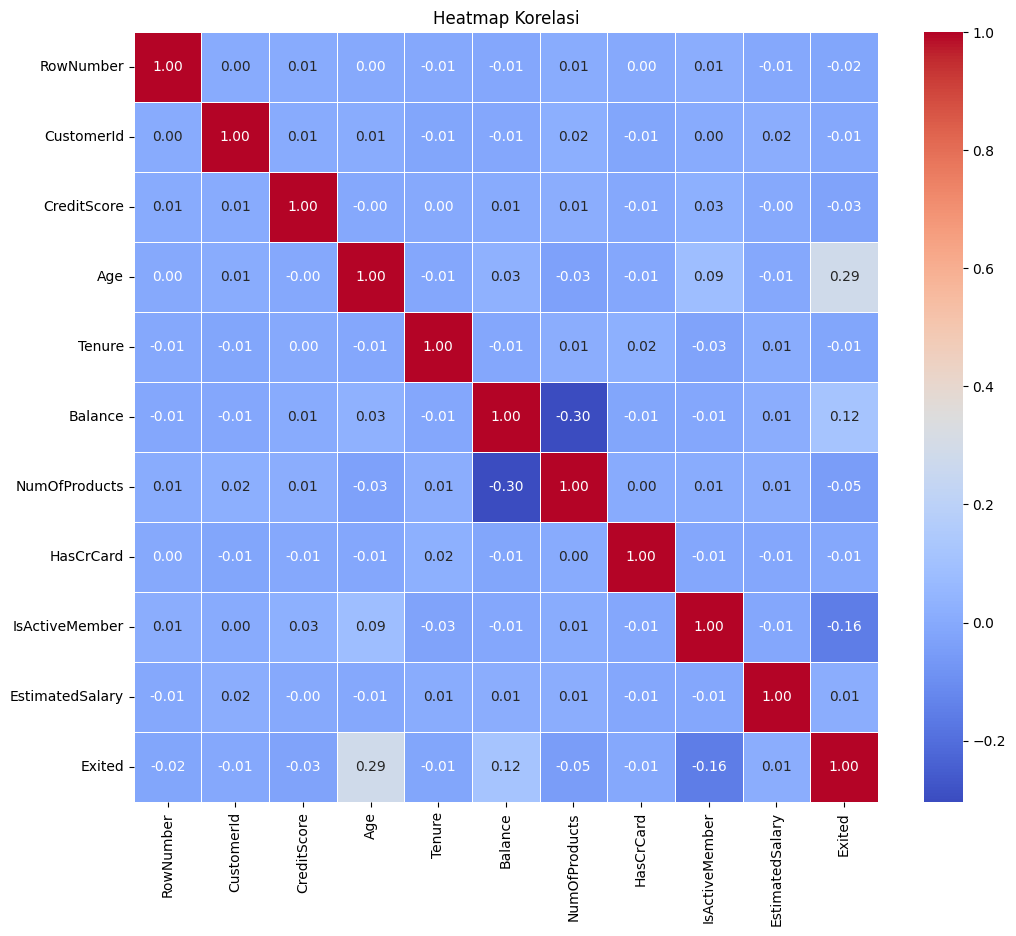

In [12]:
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

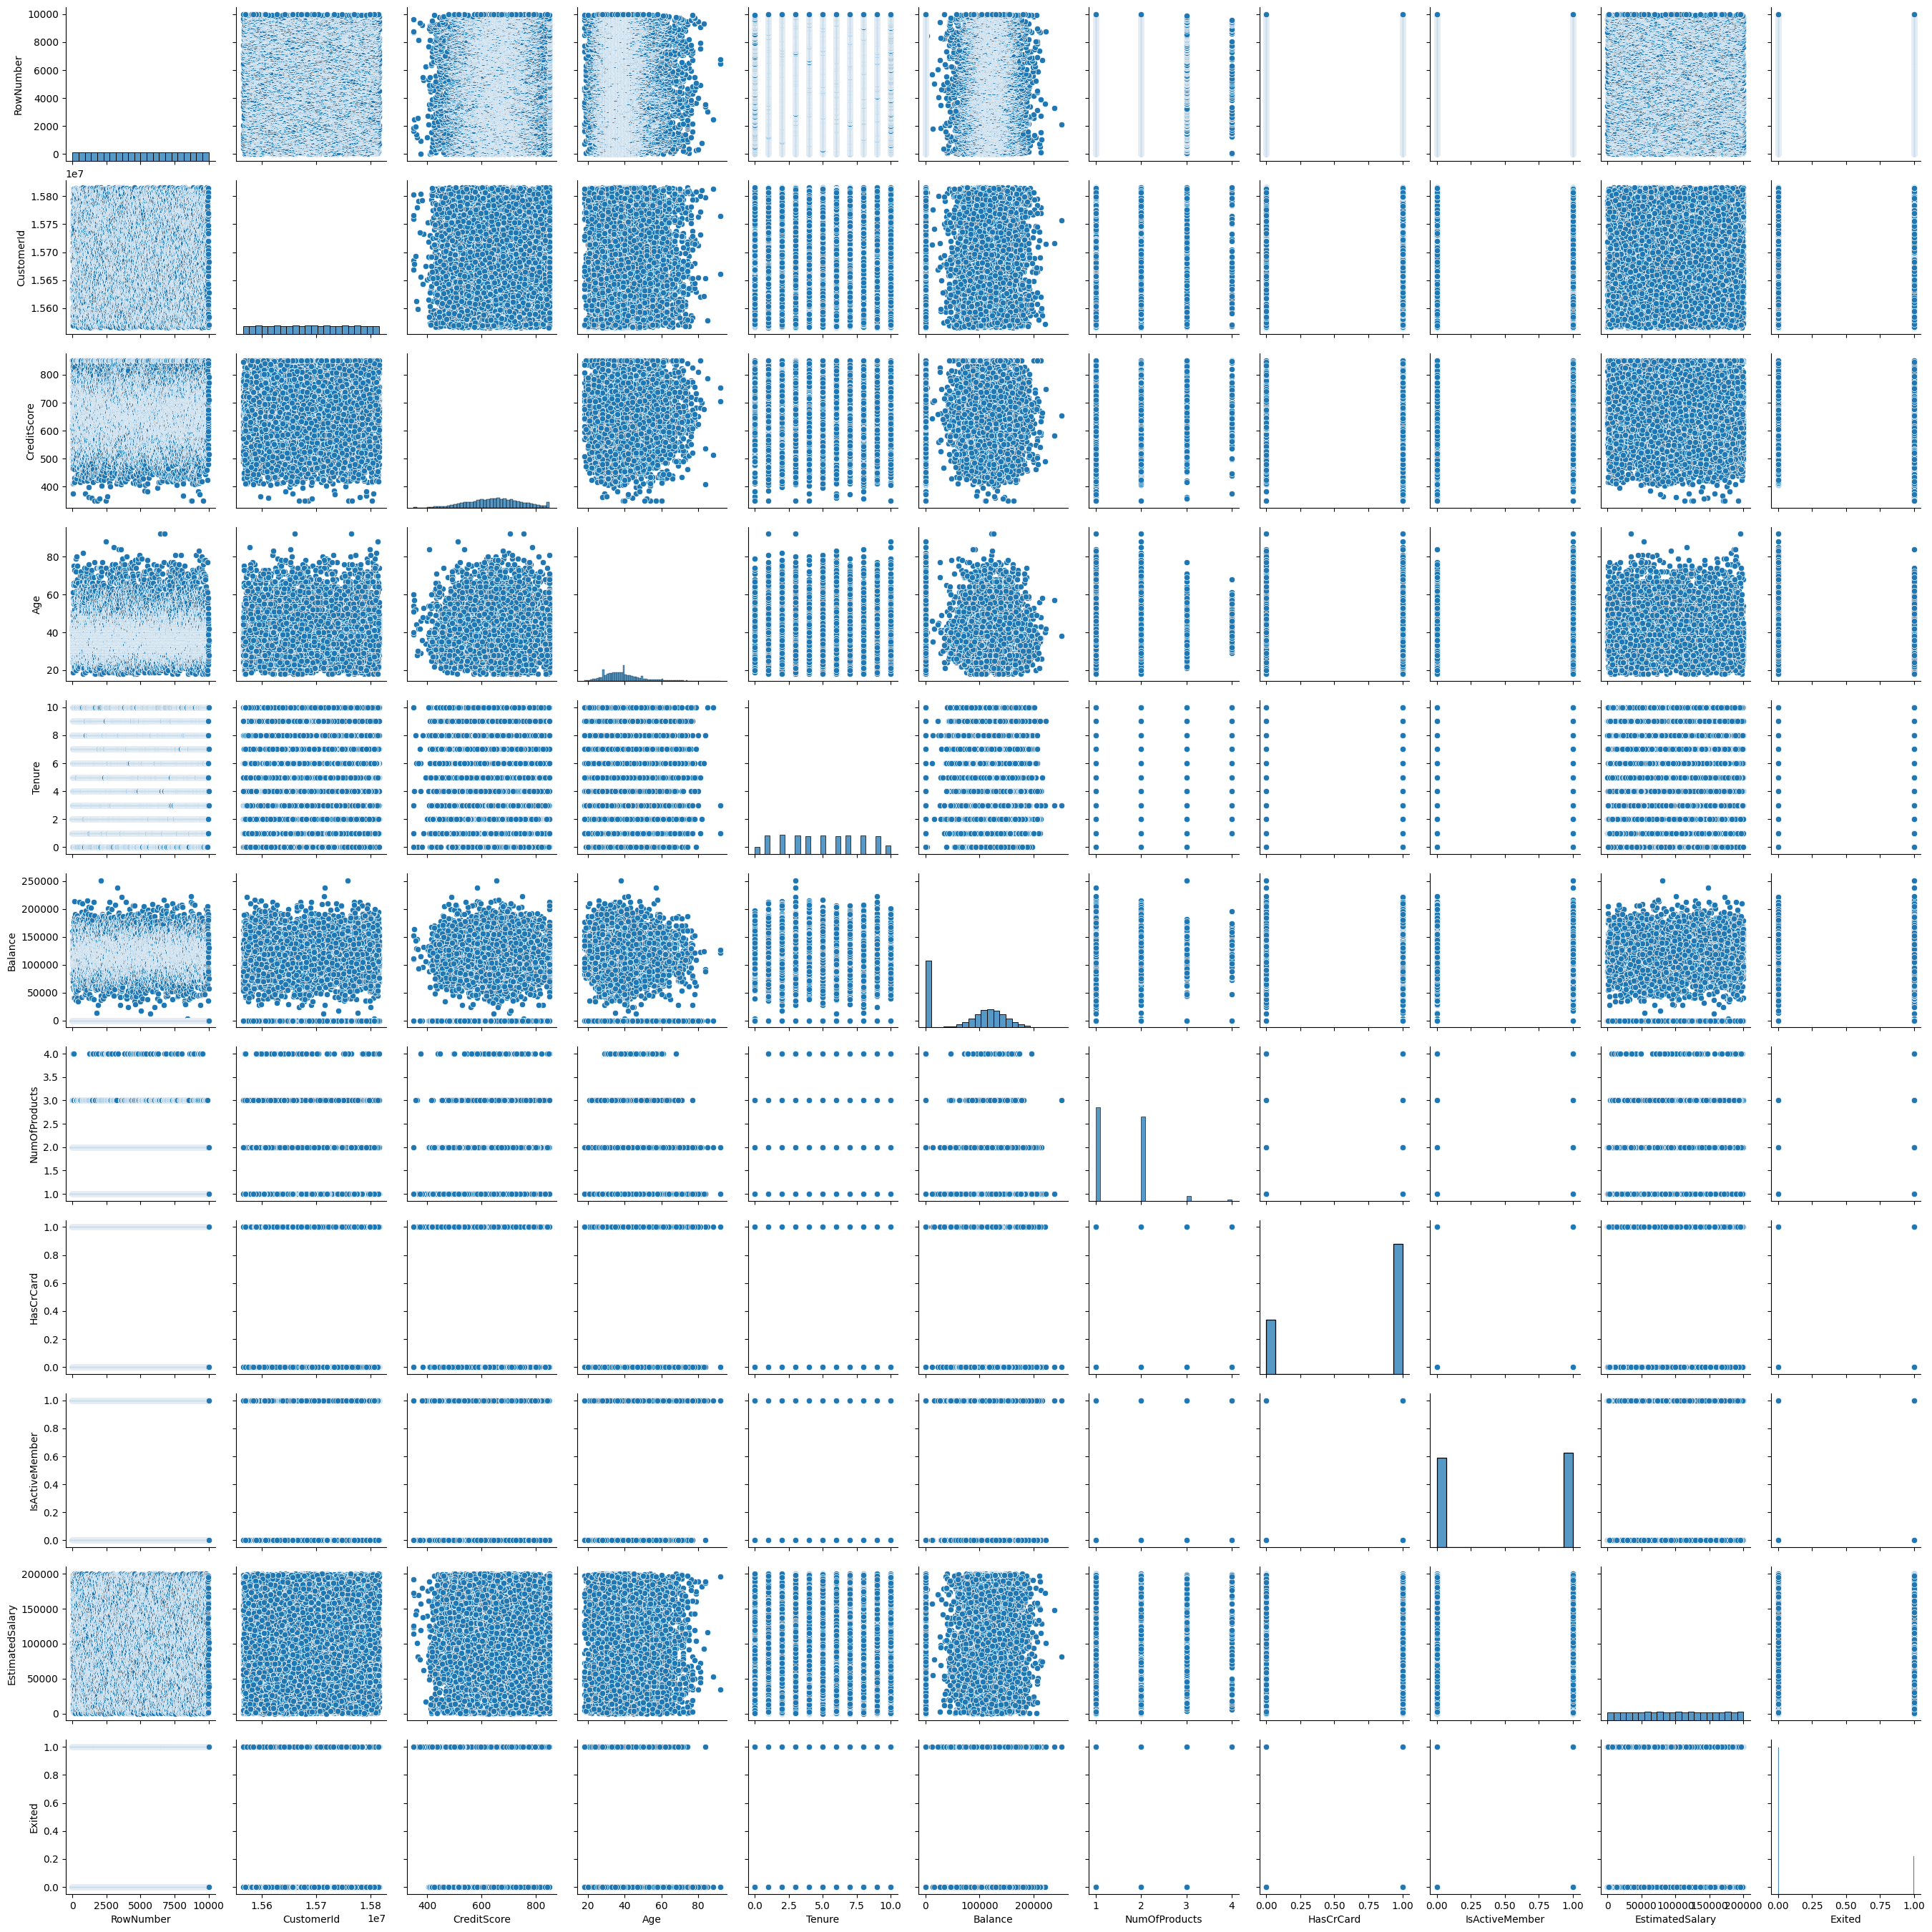

In [13]:
# Pairplot untuk fitur numerik
sns.pairplot(num_features)
plt.show()

/var/folders/x_/11jlv9j50d131r830tx300cw0000gn/T/ipykernel_4088/475290074.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=data, palette='viridis')


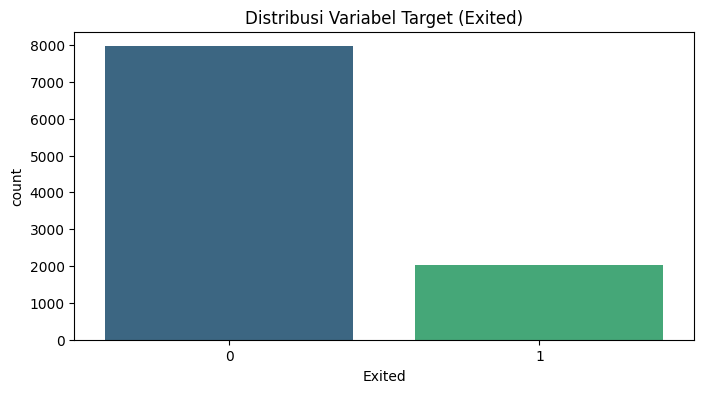

In [14]:
# Visualisasi distribusi variabel target
plt.figure(figsize=(8, 4))
sns.countplot(x='Exited', data=data, palette='viridis')
plt.title('Distribusi Variabel Target (Exited)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
# Buat instance LabelEncoder
label_encoder = LabelEncoder()

# List kolom kategorikal yang perlu di-encode
categorical_columns = ['Geography', 'Gender']

# Encode kolom kategorikal
for column in categorical_columns:
    data[column] = label_encoder.fit_transform(data[column])

# Tampilkan DataFrame untuk memastikan encoding telah diterapkan
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,2,0,43,2,125510.82,1,1,1,79084.10,0


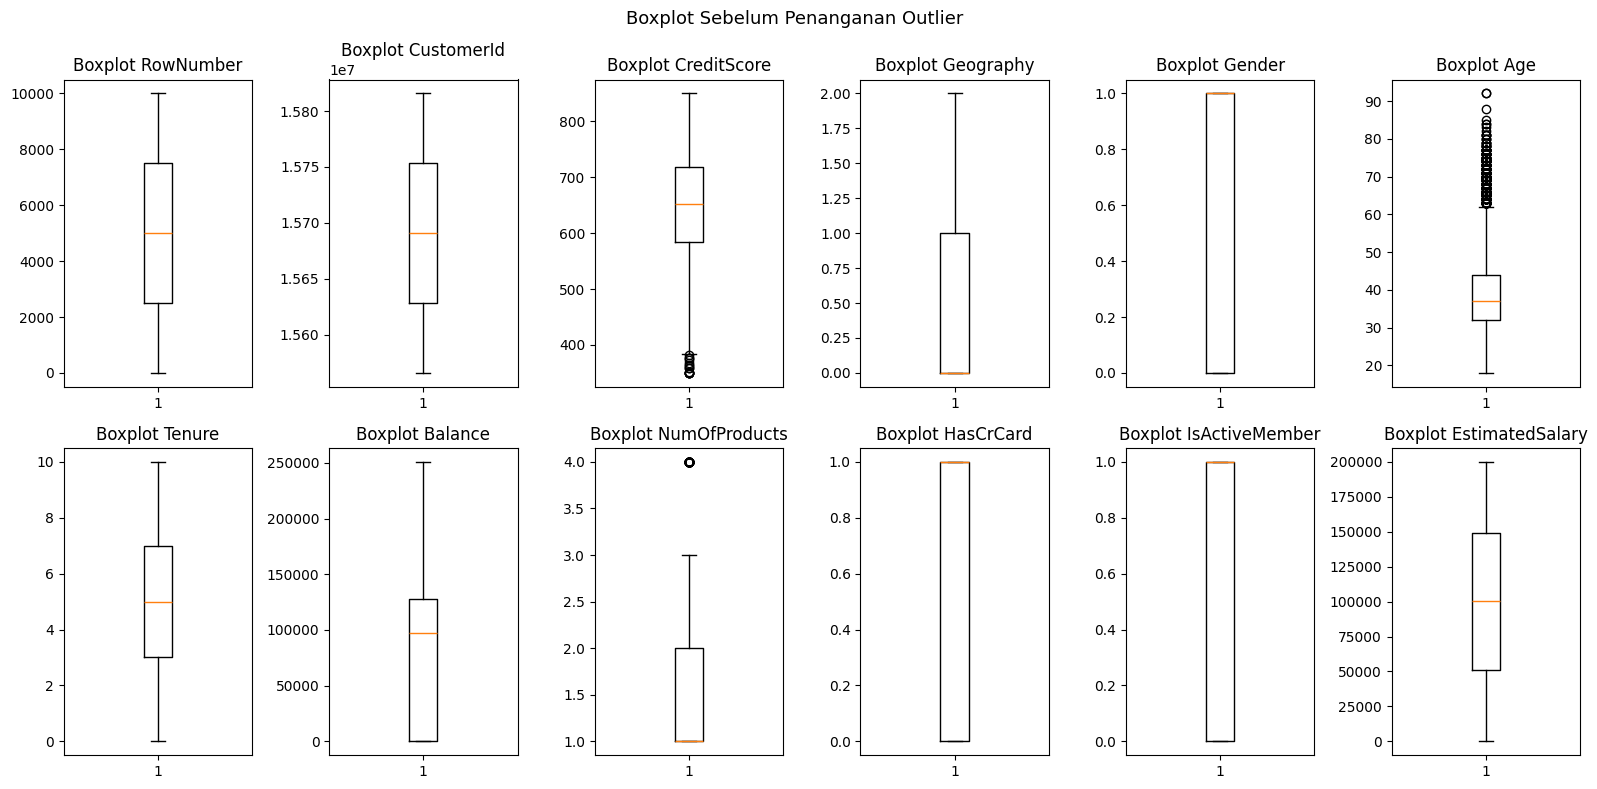


Jumlah outlier per fitur (IQR method):
  RowNumber: 0 outlier
  CustomerId: 0 outlier
  CreditScore: 15 outlier
  Geography: 0 outlier
  Gender: 0 outlier
  Age: 359 outlier
  Tenure: 0 outlier
  Balance: 0 outlier
  NumOfProducts: 60 outlier
  HasCrCard: 0 outlier
  IsActiveMember: 0 outlier
  EstimatedSalary: 0 outlier

✅ Outlier berhasil ditangani dengan IQR Capping!


In [16]:
#Deteksi data outliner

num_cols = data.select_dtypes(include=['int64','float64']).columns.tolist()
# Exclude target variable
num_cols = [c for c in num_cols if c != 'Exited']

# Visualisasi boxplot sebelum
fig, axes = plt.subplots(2, (len(num_cols)+1)//2, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(f'Boxplot {col}')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot Sebelum Penanganan Outlier', fontsize=13)
plt.tight_layout()
plt.show()

# Tangani outlier dengan IQR capping (Winsorizing)
print("\nJumlah outlier per fitur (IQR method):")
for col in num_cols:
    Q1  = data[col].quantile(0.25)
    Q3  = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)].shape[0]
    print(f"  {col}: {outliers} outlier")
    # Capping: clip nilai ke batas IQR
    data[col] = data[col].clip(lower=lower, upper=upper)

print("\n✅ Outlier berhasil ditangani dengan IQR Capping!")

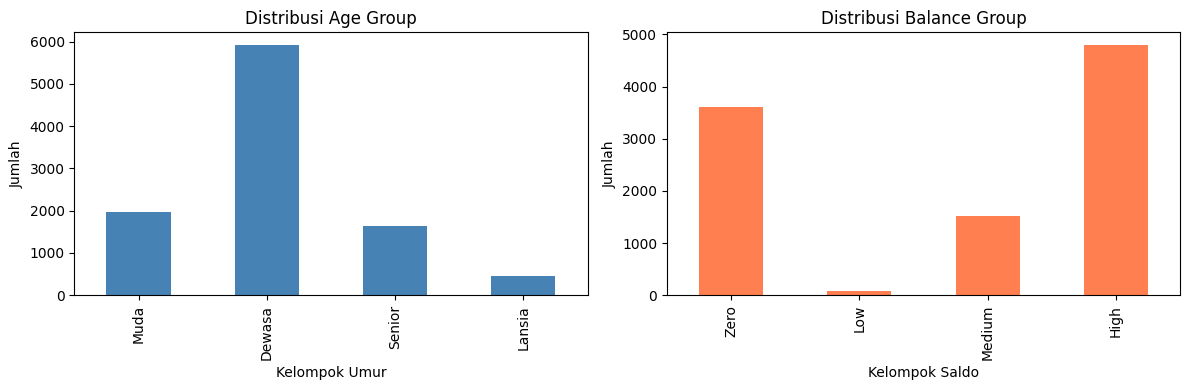

   Age Age_Group    Balance Balance_Group
0   42    Dewasa       0.00          Zero
1   41    Dewasa   83807.86        Medium
2   42    Dewasa  159660.80          High
3   39    Dewasa       0.00          Zero
4   43    Dewasa  125510.82          High
5   44    Dewasa  113755.78          High
6   50    Senior       0.00          Zero
7   29      Muda  115046.74          High
8   44    Dewasa  142051.07          High
9   27      Muda  134603.88          High

✅ Binning berhasil diterapkan!


In [17]:
# Binning kolom Age
age_bins   = [0, 30, 45, 60, 100]
age_labels = ['Muda', 'Dewasa', 'Senior', 'Lansia']
data['Age_Group'] = pd.cut(data['Age'], bins=age_bins, labels=age_labels)

# Binning kolom Balance
bal_bins   = [data['Balance'].min()-1, 0, 50000, 100000, data['Balance'].max()+1]
bal_labels = ['Zero', 'Low', 'Medium', 'High']
data['Balance_Group'] = pd.cut(data['Balance'], bins=bal_bins, labels=bal_labels)

# Visualisasi hasil binning
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['Age_Group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Age Group')
axes[0].set_xlabel('Kelompok Umur')
axes[0].set_ylabel('Jumlah')

data['Balance_Group'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribusi Balance Group')
axes[1].set_xlabel('Kelompok Saldo')
axes[1].set_ylabel('Jumlah')

plt.tight_layout()
plt.show()

print(data[['Age','Age_Group','Balance','Balance_Group']].head(10))
print("\n✅ Binning berhasil diterapkan!")

# **6. Export Hasil Preprocessing**

Setelah seluruh tahapan preprocessing selesai dilakukan (penanganan missing value, encoding, scaling, dan binning), langkah terakhir adalah menyimpan dataset yang telah diproses ke dalam file CSV. Hal ini penting agar hasil preprocessing dapat digunakan kembali tanpa harus menjalankan ulang seluruh pipeline dari awal.

In [18]:
# Simpan hasil preprocessing ke file CSV
output_filename = 'data_preprocessed.csv'
data.to_csv(output_filename, index=False)

print(f"✅ Data hasil preprocessing berhasil disimpan ke '{output_filename}'")
print(f"   Jumlah baris : {data.shape[0]}")
print(f"   Jumlah kolom : {data.shape[1]}")
print(f"\nPreview data yang disimpan:")
data.head()

✅ Data hasil preprocessing berhasil disimpan ke 'data_preprocessed.csv'
   Jumlah baris : 10000
   Jumlah kolom : 16

Preview data yang disimpan:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_Group,Balance_Group
0,1,15634602,Hargrave,619,0,0,42,2,0.00,1.0,1,1,101348.88,1,Dewasa,Zero
1,2,15647311,Hill,608,2,0,41,1,83807.86,1.0,0,1,112542.58,0,Dewasa,Medium
2,3,15619304,Onio,502,0,0,42,8,159660.80,3.0,1,0,113931.57,1,Dewasa,High
3,4,15701354,Boni,699,0,0,39,1,0.00,2.0,0,0,93826.63,0,Dewasa,Zero
4,5,15737888,Mitchell,850,2,0,43,2,125510.82,1.0,1,1,79084.10,0,Dewasa,High
